---
# 🔧 Hey Pakize — Model Düzeltme & Yeniden Eğitim

## Sorun Nedir?

Mevcut model **her şeyi 0.97-0.99** skoru ile pozitif algılıyor.
Bu bir **model eğitim sorunu** — threshold ayarıyla çözülmez.

### Kök Neden: Augmentasyon Dengesizliği

```
Orijinal kod:
  Pozitif: orijinal + noise + shift = 3×
  Negatif: sadece orijinal         = 1×

Sonuç:
  Model 'augmente ses = Hey Pakize' öğrendi
  Mikrofon sesi augmente görünüyor → hep pozitif
```

### Çözüm
Negatiflere de aynı augmentasyonu uygula → dengeli eğitim → yeniden eğit.

In [1]:
# ── Kurulum ────────────────────────────────────────────────
!pip install librosa -q
!apt-get install -y ffmpeg -q

import os, subprocess, tempfile, time
from base64 import b64decode
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)
from IPython.display import Audio, display as ipy_display
from google.colab.output import eval_js
from google.colab import drive

drive.mount('/content/drive')

# ── Sabitler (orijinal kodla aynı) ─────────────────────────
TARGET_SR       = 16000
TARGET_DURATION = 1.5
TARGET_LENGTH   = int(TARGET_SR * TARGET_DURATION)   # 24 000
N_MFCC          = 40

# ── Drive yolları (orijinal kodla aynı) ────────────────────
dataset_path  = "/content/drive/MyDrive/HONDA1"
positive_path = os.path.join(dataset_path, "Hey_Pakize_Positives")
negative_path = os.path.join(dataset_path, "Not_Hey_Pakize")
MODEL_SAVE    = "/content/drive/MyDrive/HONDA1/hey_pakize_model_v3.h5"

positive_files = sorted([f for f in os.listdir(positive_path) if f.lower().endswith('.wav')])
negative_files = sorted([f for f in os.listdir(negative_path) if f.lower().endswith('.wav')])

print(f'✅ Pozitif: {len(positive_files)} | Negatif: {len(negative_files)}')

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Mounted at /content/drive
✅ Pozitif: 126 | Negatif: 247


In [2]:
# ── Orijinal kodla BİREBİR AYNI process_audio ─────────────
def process_audio(file_path):
    y, sr = librosa.load(file_path, sr=TARGET_SR)
    y, _ = librosa.effects.trim(y, top_db=20)
    if len(y) == 0:
        return np.zeros(TARGET_LENGTH, dtype=np.float32)
    if len(y) < TARGET_LENGTH:
        y = np.pad(y, (0, TARGET_LENGTH - len(y)))
    else:
        y = y[:TARGET_LENGTH]
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val
    return y.astype(np.float32)

# ── Orijinal augmentasyon fonksiyonları ────────────────────
def add_noise(y, noise_factor=0.003):
    return (y + noise_factor * np.random.randn(len(y))).astype(np.float32)

def shift_audio(y, shift_max=0.1):
    shift = int(len(y) * np.random.uniform(-shift_max, shift_max))
    return np.roll(y, shift).astype(np.float32)

# ── Orijinal MFCC çıkarımı ─────────────────────────────────
def extract_mfcc_from_signal(y):
    mfcc   = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=N_MFCC)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    return np.vstack([mfcc, delta, delta2]).astype(np.float32)

print('✅ Fonksiyonlar hazır.')

✅ Fonksiyonlar hazır.


In [3]:
# ════════════════════════════════════════════════════════════
# DÜZELTİLMİŞ VERİ HAZIRLAMA
# Fark: Negatiflere de noise + shift augmentasyonu uygulanır
# ════════════════════════════════════════════════════════════
X, y_labels = [], []

# ── Pozitifler: orijinal + noise + shift (×3) ─────────────
print('🔄 Pozitifler işleniyor...')
for file in positive_files:
    fp = os.path.join(positive_path, file)
    try:
        sig = process_audio(fp)

        X.append(extract_mfcc_from_signal(sig));          y_labels.append(1)  # orijinal
        X.append(extract_mfcc_from_signal(add_noise(sig)));  y_labels.append(1)  # noise
        X.append(extract_mfcc_from_signal(shift_audio(sig))); y_labels.append(1)  # shift
    except Exception as e:
        print(f'  HATA {file}: {e}')

# ── Negatifler: orijinal + noise + shift (×3) ─────────────
# ↑ DÜZELTME: Orijinal kodda negatifler ×1'di.
# Şimdi pozitiflerle EŞİT augmentasyon uygulanıyor.
print('🔄 Negatifler işleniyor...')
for file in negative_files:
    fp = os.path.join(negative_path, file)
    try:
        sig = process_audio(fp)

        X.append(extract_mfcc_from_signal(sig));           y_labels.append(0)  # orijinal
        X.append(extract_mfcc_from_signal(add_noise(sig)));   y_labels.append(0)  # noise
        X.append(extract_mfcc_from_signal(shift_audio(sig)));  y_labels.append(0)  # shift
    except Exception as e:
        print(f'  HATA {file}: {e}')

X        = np.array(X,        dtype=np.float32)[..., np.newaxis]
y_labels = np.array(y_labels, dtype=np.int32)

print(f'\n✅ X shape  : {X.shape}')
print(f'   Pozitif : {np.sum(y_labels == 1)}')
print(f'   Negatif : {np.sum(y_labels == 0)}')
print(f'   Oran    : {np.sum(y_labels==0)/np.sum(y_labels==1):.2f}x (1.0 ideal)')

🔄 Pozitifler işleniyor...


/tmp/ipykernel_1661/996867575.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=TARGET_SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


🔄 Negatifler işleniyor...


/tmp/ipykernel_1661/996867575.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=TARGET_SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1661/996867575.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=TARGET_SR)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



✅ X shape  : (1119, 120, 47, 1)
   Pozitif : 378
   Negatif : 741
   Oran    : 1.96x (1.0 ideal)


In [4]:
# ── Train / Val / Test split ───────────────────────────────
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print(f'Train : {X_train.shape}  Pos={np.sum(y_train==1)}  Neg={np.sum(y_train==0)}')
print(f'Val   : {X_val.shape}   Pos={np.sum(y_val==1)}    Neg={np.sum(y_val==0)}')
print(f'Test  : {X_test.shape}  Pos={np.sum(y_test==1)}   Neg={np.sum(y_test==0)}')

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print(f'\nClass weight: {class_weight}')

Train : (895, 120, 47, 1)  Pos=302  Neg=593
Val   : (112, 120, 47, 1)   Pos=38    Neg=74
Test  : (112, 120, 47, 1)  Pos=38   Neg=74

Class weight: {0: 0.7546374367622259, 1: 1.4817880794701987}


In [5]:
# ── Model (orijinal mimariyle aynı) ───────────────────────
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 47, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 23, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10560)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       675,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 680,769 (2.60 MB)

 Trainable params: 680,769 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.5274 - loss: 1.7993 - val_accuracy: 0.5446 - val_loss: 0.6408
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5832 - loss: 0.6129 - val_accuracy: 0.6161 - val_loss: 0.5600
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7128 - loss: 0.5179 - val_accuracy: 0.7411 - val_loss: 0.4561
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7374 - loss: 0.4280 - val_accuracy: 0.7946 - val_loss: 0.3619
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7743 - loss: 0.3670 - val_accuracy: 0.8750 - val_loss: 0.2627
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7676 - loss: 0.3372 - val_accuracy: 0.8393 - val_loss: 0.2885
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8525 - loss: 0.2702 - val_accuracy: 0.8571 - val_loss: 0.2485
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8447 - loss: 0.2693 - val_accuracy: 0.8482 - val_loss

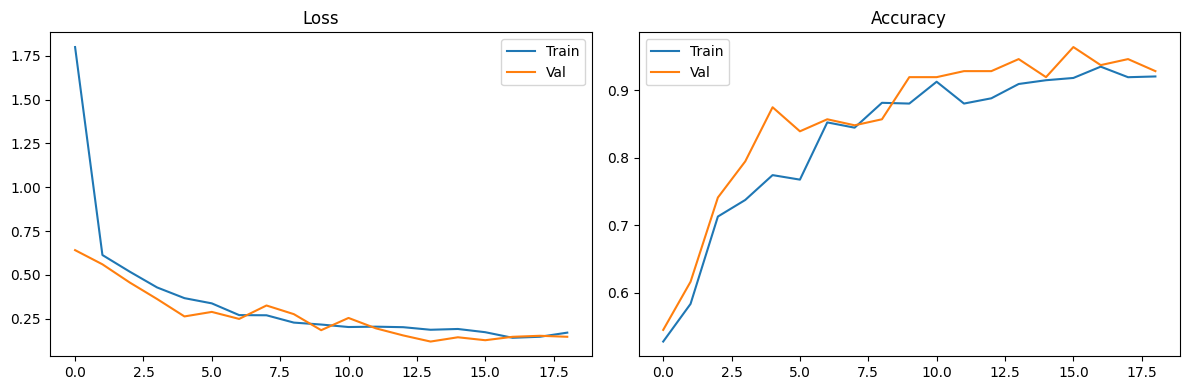

In [6]:
# ── Eğitim ────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    class_weight=class_weight,
    callbacks=[early_stop],
)

# Loss + Accuracy grafik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout(); plt.show()

🏆 Optimal Threshold : 0.60
   F1=0.961  Prec=0.949  Recall=0.974


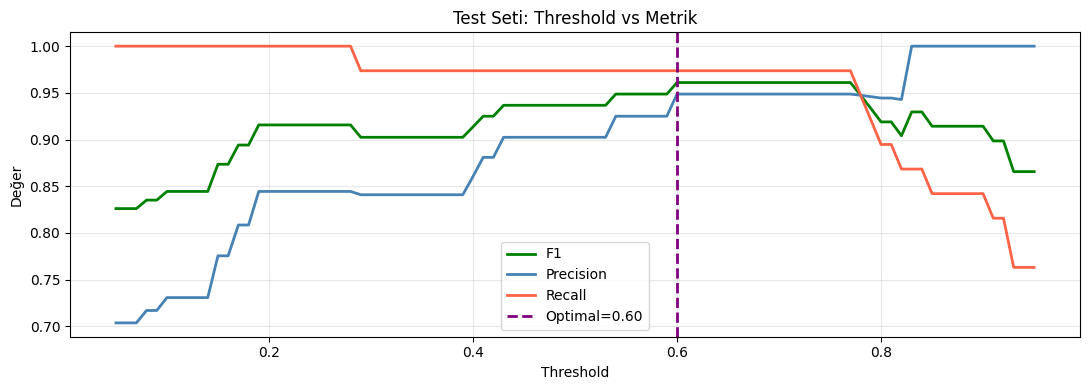

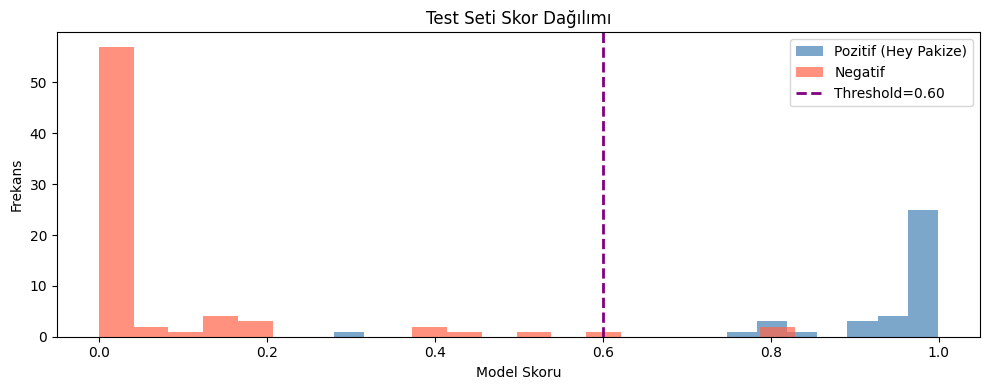

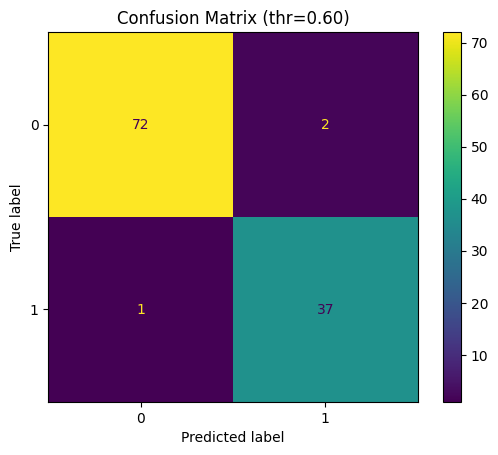


              precision    recall  f1-score   support

     Negatif       0.99      0.97      0.98        74
  Hey Pakize       0.95      0.97      0.96        38

    accuracy                           0.97       112
   macro avg       0.97      0.97      0.97       112
weighted avg       0.97      0.97      0.97       112



In [9]:
# ════════════════════════════════════════════════════════════
# OPTİMAL THRESHOLD BULMA
# Test seti üzerinde F1 maksimize eden eşiği bul
# ════════════════════════════════════════════════════════════
y_prob = model.predict(X_test, verbose=0).ravel()

# Her threshold için F1 hesapla
thresholds  = np.linspace(0.05, 0.95, 91)
f1_scores   = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
prec_scores = [precision_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
rec_scores  = [recall_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]

best_idx  = int(np.argmax(f1_scores))
THRESHOLD = float(thresholds[best_idx])

print(f'🏆 Optimal Threshold : {THRESHOLD:.2f}')
print(f'   F1={f1_scores[best_idx]:.3f}  '
      f'Prec={prec_scores[best_idx]:.3f}  '
      f'Recall={rec_scores[best_idx]:.3f}')

# Grafik
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(thresholds, f1_scores,   lw=2, color='green',     label='F1')
ax.plot(thresholds, prec_scores, lw=2, color='steelblue', label='Precision')
ax.plot(thresholds, rec_scores,  lw=2, color='tomato',    label='Recall')
ax.axvline(THRESHOLD, color='purple', ls='--', lw=2,
           label=f'Optimal={THRESHOLD:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Değer')
ax.set_title('Test Seti: Threshold vs Metrik')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Skor dağılımı histogramı
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob[y_test == 1], bins=20, alpha=0.7, color='steelblue', label='Pozitif (Hey Pakize)')
ax.hist(y_prob[y_test == 0], bins=20, alpha=0.7, color='tomato',    label='Negatif')
ax.axvline(THRESHOLD, color='purple', ls='--', lw=2, label=f'Threshold={THRESHOLD:.2f}')
ax.set_xlabel('Model Skoru'); ax.set_ylabel('Frekans')
ax.set_title('Test Seti Skor Dağılımı')
ax.legend(); plt.tight_layout(); plt.show()

# Confusion matrix
y_pred = (y_prob >= THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title(f'Confusion Matrix (thr={THRESHOLD:.2f})')
plt.show()

print()
print(classification_report(y_test, y_pred, target_names=['Negatif','Hey Pakize']))

In [10]:
# ── Modeli kaydet ─────────────────────────────────────────
model.save(MODEL_SAVE)
print(f'✅ Model kaydedildi: {MODEL_SAVE}')
print(f'   Threshold: {THRESHOLD:.3f}')

# Threshold'u da kaydet (bir sonraki oturumda kullanmak için)
import json
meta = {'threshold': THRESHOLD, 'target_sr': TARGET_SR,
        'target_duration': TARGET_DURATION, 'n_mfcc': N_MFCC}
meta_path = MODEL_SAVE.replace('.h5', '_meta.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f)
print(f'✅ Meta kaydedildi : {meta_path}')

✅ Model kaydedildi: /content/drive/MyDrive/HONDA1/hey_pakize_model_v3.h5
   Threshold: 0.600
✅ Meta kaydedildi : /content/drive/MyDrive/HONDA1/hey_pakize_model_v3_meta.json


---
## 🎙️ Canlı Mikrofon

In [11]:
# ── Mikrofon fonksiyonları ────────────────────────────────
RECORD_JS = """
async function record(sec) {
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const rec = new MediaRecorder(stream);
  const chunks = [];
  rec.ondataavailable = e => chunks.push(e.data);
  rec.start();
  await new Promise(r => setTimeout(r, sec*1000));
  rec.stop();
  await new Promise(r => rec.onstop = r);
  stream.getTracks().forEach(t => t.stop());
  const blob = new Blob(chunks);
  const reader = new FileReader();
  reader.readAsDataURL(blob);
  await new Promise(r => reader.onload = r);
  return reader.result;
}
record(SECS);
"""

def record_from_mic(sec=3):
    data = eval_js(RECORD_JS.replace('SECS', str(sec)))
    _, b64 = data.split(',', 1)
    with tempfile.NamedTemporaryFile(suffix='.webm', delete=False) as f:
        f.write(b64decode(b64)); webm = f.name
    wav = webm.replace('.webm', '.wav')
    subprocess.run(['ffmpeg','-y','-i',webm,
                    '-ar',str(TARGET_SR),'-ac','1',
                    '-acodec','pcm_s16le', wav],
                   capture_output=True, check=True)
    y, _ = librosa.load(wav, sr=TARGET_SR, mono=True)
    os.unlink(webm); os.unlink(wav)
    return y


def predict_mic(y_raw, thr=None):
    """Kayan pencere ile tahmin — eğitimle aynı pipeline."""
    thr = thr or THRESHOLD
    hop = int(0.25 * TARGET_SR)

    windows = []
    segments = ([y_raw] if len(y_raw) <= TARGET_LENGTH
                else [y_raw[s:s+TARGET_LENGTH]
                      for s in range(0, len(y_raw)-TARGET_LENGTH+1, hop)])

    for i, seg in enumerate(segments):
        # Eğitimle aynı işlem: trim → pad/crop → normalize
        y_t, _ = librosa.effects.trim(seg, top_db=20)
        if len(y_t) < 100: y_t = seg
        if len(y_t) < TARGET_LENGTH:
            y_t = np.pad(y_t, (0, TARGET_LENGTH - len(y_t)))
        else:
            y_t = y_t[:TARGET_LENGTH]
        mv = np.max(np.abs(y_t))
        if mv > 0: y_t = y_t / mv

        feat  = extract_mfcc_from_signal(y_t.astype(np.float32))
        score = float(model.predict(feat[np.newaxis,...,np.newaxis], verbose=0)[0][0])
        windows.append((i * hop / TARGET_SR, score))

    best = max(s for _, s in windows)
    return {'score': best, 'is_wake': best >= thr,
            'threshold': thr, 'windows': windows}


def show_result(res, y_raw):
    print('━'*50)
    print('  ✅  HEY PAKİZE!' if res['is_wake'] else '  ❌  Algılanmadı.')
    print(f'  Skor={res["score"]:.4f}  Thr={res["threshold"]:.3f}')
    print('━'*50)

    if len(res['windows']) > 1:
        ts = [t for t,_ in res['windows']]
        ss = [s for _,s in res['windows']]
        fig, ax = plt.subplots(figsize=(10,3))
        clrs = ['green' if s >= res['threshold'] else 'tomato' for s in ss]
        ax.bar(ts, ss, width=0.2, color=clrs, alpha=0.85)
        ax.axhline(res['threshold'], color='purple', ls='--', lw=2,
                   label=f'Thr={res["threshold"]:.3f}')
        ax.set_ylim(0,1.05); ax.set_xlabel('Zaman (s)'); ax.set_ylabel('Skor')
        ax.set_title('Sliding Window')
        ax.legend(); plt.tight_layout(); plt.show()

    ipy_display(Audio(y_raw, rate=TARGET_SR))

print(f'✅ Hazır.  Threshold={THRESHOLD:.3f}')

✅ Hazır.  Threshold=0.600


🎙️  3s kayıt...  "Hey Pakize" deyin!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅  HEY PAKİZE!
  Skor=0.9872  Thr=0.600
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


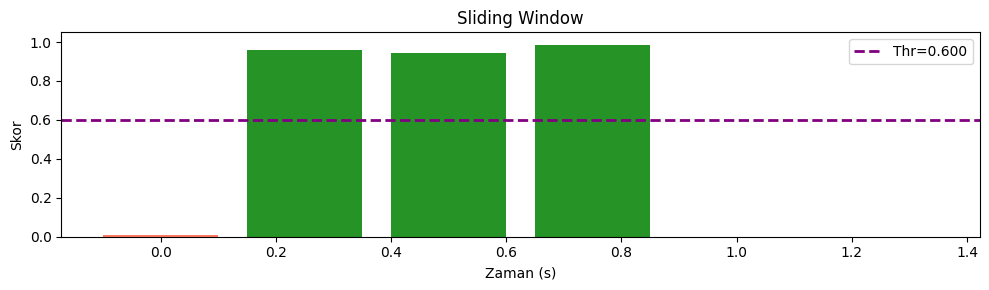

In [27]:
# 🎙️ Tek Kayıt
RECORD_SEC = 3
print(f'🎙️  {RECORD_SEC}s kayıt...  "Hey Pakize" deyin!')
y = record_from_mic(RECORD_SEC)
res = predict_mic(y)
show_result(res, y)

In [29]:
# 🔄 Döngüsel izleme
N, SEC = 5, 3
log = []
print(f'🔄 {N} tur ({SEC}s/tur)  Thr={THRESHOLD:.3f}\n')
for i in range(N):
    print(f'Tur {i+1}/{N} — 🎙️  Konuşun...')
    try:
        y = record_from_mic(SEC)
        r = predict_mic(y)
        st = '✅ HEY PAKİZE!' if r['is_wake'] else '❌ Hayır'
        print(f'  → {st:<18}  Skor={r["score"]:.4f}')
        log.append({'tur':i+1,'wake':int(r['is_wake']),'skor':round(r['score'],4)})
    except Exception as e:
        print(f'  ⚠️ {e}')
    time.sleep(0.3)

df = pd.DataFrame(log)
print(f'\nWake: {df["wake"].sum()}/{N}  Ort skor: {df["skor"].mean():.4f}')
ipy_display(df)

🔄 5 tur (3s/tur)  Thr=0.600

Tur 1/5 — 🎙️  Konuşun...
  → ✅ HEY PAKİZE!       Skor=0.9510
Tur 2/5 — 🎙️  Konuşun...
  → ❌ Hayır             Skor=0.1757
Tur 3/5 — 🎙️  Konuşun...
  → ❌ Hayır             Skor=0.0020
Tur 4/5 — 🎙️  Konuşun...
  → ✅ HEY PAKİZE!       Skor=0.9362
Tur 5/5 — 🎙️  Konuşun...
  → ✅ HEY PAKİZE!       Skor=0.9742

Wake: 3/5  Ort skor: 0.6078


,tur,wake,skor
0,1,1,0.9510
1,2,0,0.1757
2,3,0,0.0020
3,4,1,0.9362
4,5,1,0.9742


📂 WAV dosyası seçin...


Saving Hakan_Karakaya_wake_1.wav to Hakan_Karakaya_wake_1.wav

📄 Hakan_Karakaya_wake_1.wav  (3.96s)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅  HEY PAKİZE!
  Skor=0.9806  Thr=0.600
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


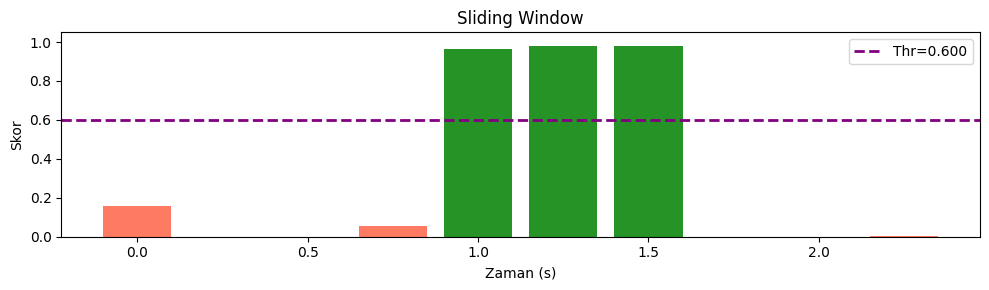

In [48]:
# ═══════════════════════════════════════════════════════════
# 📁  DOSYA YÜKLEME — Bilgisayardan
# ═══════════════════════════════════════════════════════════
from google.colab import files
print('📂 WAV dosyası seçin...')
uploaded = files.upload()

for fname, data in uploaded.items():
    tmp = f'/tmp/{fname}'
    with open(tmp, 'wb') as f: f.write(data)

    y_f, sr_f = librosa.load(tmp, sr=TARGET_SR, mono=True)
    print(f'\n📄 {fname}  ({len(y_f)/TARGET_SR:.2f}s)')

    res = predict_mic(y_f)
    show_result(res, y_f)
    os.unlink(tmp)